In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv('data/job_salary_prediction_dataset.csv')
data

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467


In [3]:
df=pd.DataFrame(data)
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467


#### The original data is clean so we are going to create some duplicates ,and missing vales 

In [4]:
df['skills_count_copy']=df['skills_count']
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,skills_count_copy
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413,2
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764,17
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123,4
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123,13
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069,7
...,...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791,2
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593,7
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988,12
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467,2


In [5]:
df.loc[5,'experience_years']=np.nan
df.loc[1,'skills_count']=np.nan
df.loc[3, 'certifications'] = np.nan
df.loc[10,'job_title']=np.nan
df.loc[249999,'education_level']=np.nan
df.loc[4,'industry']=np.nan
df.loc[249998,'location']=np.nan
df.loc[1,'salary']=np.nan
df.loc[49000,'company_size']=np.nan
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,skills_count_copy
0,AI Engineer,10.0,Bachelor,2.0,Healthcare,Medium,India,Hybrid,2.0,109413.0,2
1,Data Analyst,5.0,Bachelor,NaN,Telecom,Small,Australia,No,0.0,NaN,17
2,Frontend Developer,18.0,PhD,4.0,Media,Medium,Singapore,No,1.0,148123.0,4
3,Business Analyst,19.0,PhD,13.0,Retail,Medium,Canada,Yes,NaN,189123.0,13
4,Product Manager,15.0,Bachelor,7.0,NaN,Large,Sweden,Yes,0.0,165069.0,7
...,...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17.0,PhD,2.0,Telecom,Enterprise,India,No,1.0,127791.0,2
249996,Frontend Developer,20.0,PhD,7.0,Telecom,Startup,Remote,No,2.0,154593.0,7
249997,Business Analyst,1.0,Bachelor,12.0,Retail,Enterprise,India,Yes,0.0,75988.0,12
249998,Data Scientist,0.0,High School,2.0,Consulting,Small,NaN,Hybrid,5.0,90467.0,2


In [6]:
df_replicated = pd.concat([df.iloc[[4]*2],df.iloc[[566]*2]], ignore_index=True)
df = pd.concat([df, df_replicated], ignore_index=True)
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,skills_count_copy
0,AI Engineer,10.0,Bachelor,2.0,Healthcare,Medium,India,Hybrid,2.0,109413.0,2
1,Data Analyst,5.0,Bachelor,NaN,Telecom,Small,Australia,No,0.0,NaN,17
2,Frontend Developer,18.0,PhD,4.0,Media,Medium,Singapore,No,1.0,148123.0,4
3,Business Analyst,19.0,PhD,13.0,Retail,Medium,Canada,Yes,NaN,189123.0,13
4,Product Manager,15.0,Bachelor,7.0,NaN,Large,Sweden,Yes,0.0,165069.0,7
...,...,...,...,...,...,...,...,...,...,...,...
249999,Data Analyst,16.0,NaN,2.0,Technology,Medium,UK,No,5.0,133084.0,2
250000,Product Manager,15.0,Bachelor,7.0,NaN,Large,Sweden,Yes,0.0,165069.0,7
250001,Product Manager,15.0,Bachelor,7.0,NaN,Large,Sweden,Yes,0.0,165069.0,7
250002,AI Engineer,20.0,High School,13.0,Retail,Startup,Remote,No,0.0,155205.0,13


## DATA CLEANING

In [7]:
dups = df.duplicated()
print(dups)
# report if there are any duplicates using the "any" function
print(dups.any())
# list all duplicate rows from the "df" data
print(df[dups])

0         False
1         False
2         False
3         False
4         False
          ...  
249999    False
250000     True
250001     True
250002     True
250003     True
Length: 250004, dtype: bool
True
              job_title  experience_years education_level  skills_count  \
250000  Product Manager              15.0        Bachelor           7.0   
250001  Product Manager              15.0        Bachelor           7.0   
250002      AI Engineer              20.0     High School          13.0   
250003      AI Engineer              20.0     High School          13.0   

       industry company_size location remote_work  certifications    salary  \
250000      NaN        Large   Sweden         Yes             0.0  165069.0   
250001      NaN        Large   Sweden         Yes             0.0  165069.0   
250002   Retail      Startup   Remote          No             0.0  155205.0   
250003   Retail      Startup   Remote          No             0.0  155205.0   

        skills_coun

In [8]:
df.drop_duplicates(inplace=True)
df.drop(columns=['skills_count_copy'],inplace=True)
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10.0,Bachelor,2.0,Healthcare,Medium,India,Hybrid,2.0,109413.0
1,Data Analyst,5.0,Bachelor,NaN,Telecom,Small,Australia,No,0.0,NaN
2,Frontend Developer,18.0,PhD,4.0,Media,Medium,Singapore,No,1.0,148123.0
3,Business Analyst,19.0,PhD,13.0,Retail,Medium,Canada,Yes,NaN,189123.0
4,Product Manager,15.0,Bachelor,7.0,NaN,Large,Sweden,Yes,0.0,165069.0
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17.0,PhD,2.0,Telecom,Enterprise,India,No,1.0,127791.0
249996,Frontend Developer,20.0,PhD,7.0,Telecom,Startup,Remote,No,2.0,154593.0
249997,Business Analyst,1.0,Bachelor,12.0,Retail,Enterprise,India,Yes,0.0,75988.0
249998,Data Scientist,0.0,High School,2.0,Consulting,Small,NaN,Hybrid,5.0,90467.0


In [9]:
df['skills_count'] = df['skills_count'].fillna(df['skills_count'].mean())
df['salary'] = df['salary'].fillna(df['salary'].mean())
df['experience_years'] = df['experience_years'].fillna(df['experience_years'].mean())
df['industry'] = df['industry'].fillna('Manufacturing')
df['certifications'] = df['certifications'].fillna('certifications')  
df['job_title'] = df['job_title'].fillna('Frontend Developer')
df['education_level'] = df['education_level'].fillna('High School')
df['location'] = df['location'].fillna('India')
df['company_size'] = df['company_size'].fillna('Startup')
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10.0,Bachelor,2.000000,Healthcare,Medium,India,Hybrid,2.0,109413.000000
1,Data Analyst,5.0,Bachelor,9.997784,Telecom,Small,Australia,No,0.0,145718.288341
2,Frontend Developer,18.0,PhD,4.000000,Media,Medium,Singapore,No,1.0,148123.000000
3,Business Analyst,19.0,PhD,13.000000,Retail,Medium,Canada,Yes,certifications,189123.000000
4,Product Manager,15.0,Bachelor,7.000000,Manufacturing,Large,Sweden,Yes,0.0,165069.000000
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17.0,PhD,2.000000,Telecom,Enterprise,India,No,1.0,127791.000000
249996,Frontend Developer,20.0,PhD,7.000000,Telecom,Startup,Remote,No,2.0,154593.000000
249997,Business Analyst,1.0,Bachelor,12.000000,Retail,Enterprise,India,Yes,0.0,75988.000000
249998,Data Scientist,0.0,High School,2.000000,Consulting,Small,India,Hybrid,5.0,90467.000000


In [10]:
df['experience_years'] = df['experience_years'].astype(int)
df['skills_count'] = df['skills_count'].astype(int)
df['salary'] = df['salary'].astype(int)
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2.0,109413
1,Data Analyst,5,Bachelor,9,Telecom,Small,Australia,No,0.0,145718
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1.0,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,certifications,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0.0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1.0,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2.0,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0.0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,India,Hybrid,5.0,90467


In [11]:
df.describe()

,experience_years,skills_count,salary
count,250000.000000,250000.000000,250000.000000
mean,10.005448,9.997780,145718.288340
std,6.060569,5.479271,37407.808415
min,0.000000,1.000000,31867.000000
25%,5.000000,5.000000,119358.000000
50%,10.000000,10.000000,143453.000000
75%,15.000000,15.000000,169492.000000
max,20.000000,19.000000,333046.000000


## DATA VISUALIZATION

### Histogram

Text(0, 0.5, 'Frequency')

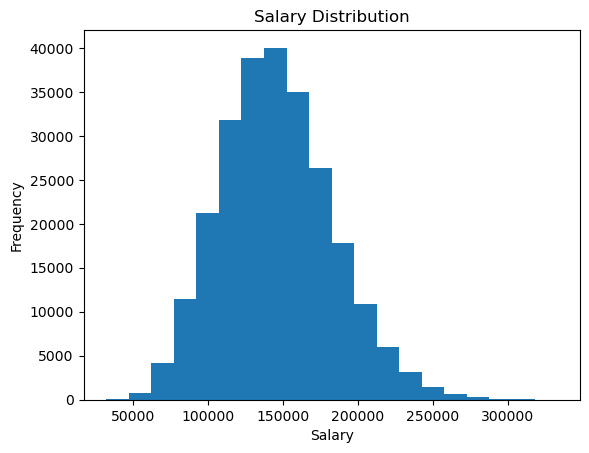

In [12]:
fig, ax = plt.subplots()

ax.hist(df['salary'], bins=20)  

ax.set_title('Salary Distribution')
ax.set_xlabel('Salary')
ax.set_ylabel('Frequency')

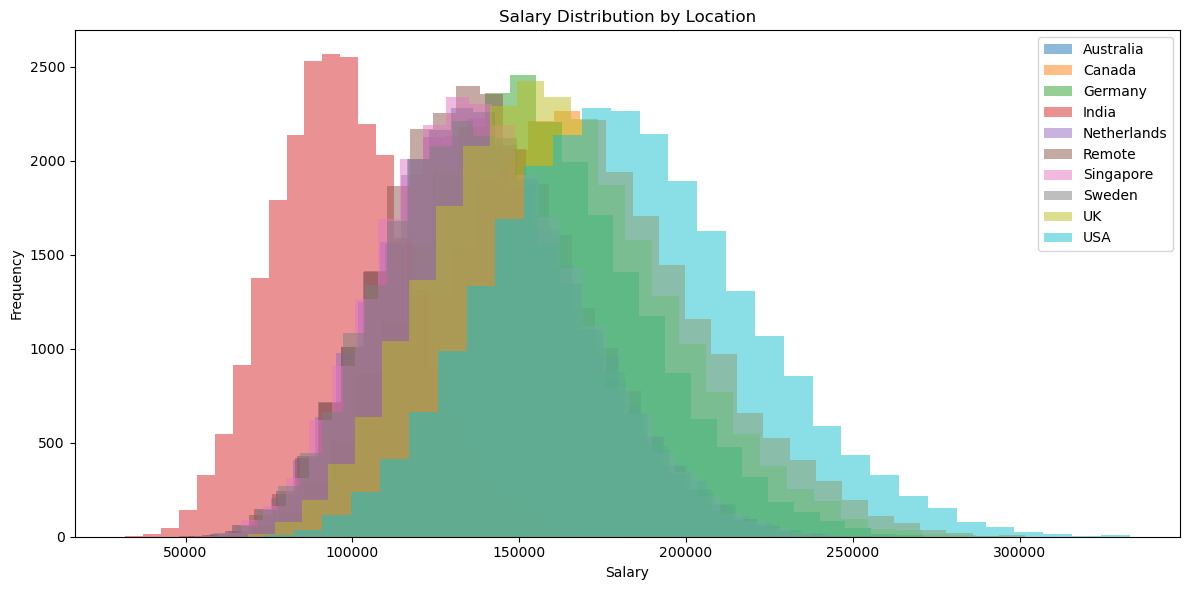

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

for loc, group in df.groupby('location')['salary']:
    ax.hist(group, alpha=0.5, label=loc, bins=30)

ax.set_title('Salary Distribution by Location')
ax.set_xlabel('Salary')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
data = df.groupby('location')['salary'].mean().sort_values(ascending=False)
print(data)

location
USA            181716.303919
Canada         167391.273396
UK             160075.143018
Germany        153376.211000
Sweden         139442.588510
Remote         139442.525155
Australia      139364.207736
Singapore      139340.696625
Netherlands    139294.813644
India           97690.112106
Name: salary, dtype: float64


### Bar Chart

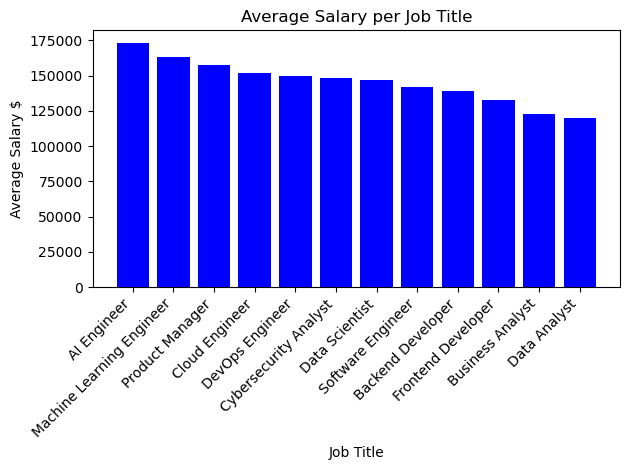

In [15]:
data = df.groupby('job_title')['salary'].mean().sort_values(ascending=False)

fig, ax = plt.subplots()
ax.bar(data.index, data.values, color='blue')
ax.set_title('Average Salary per Job Title')
ax.set_xlabel('Job Title')
ax.set_ylabel('Average Salary $')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

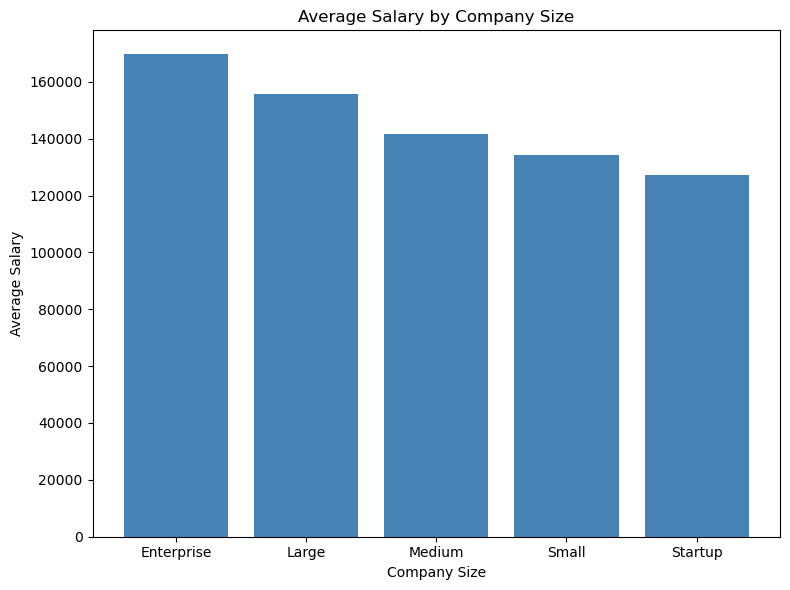

In [16]:
data = df.groupby('company_size')['salary'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(data.index, data.values, color='steelblue')
ax.set_title('Average Salary by Company Size')
ax.set_xlabel('Company Size')
ax.set_ylabel('Average Salary')
plt.tight_layout()
plt.show()

### Scatter Plot

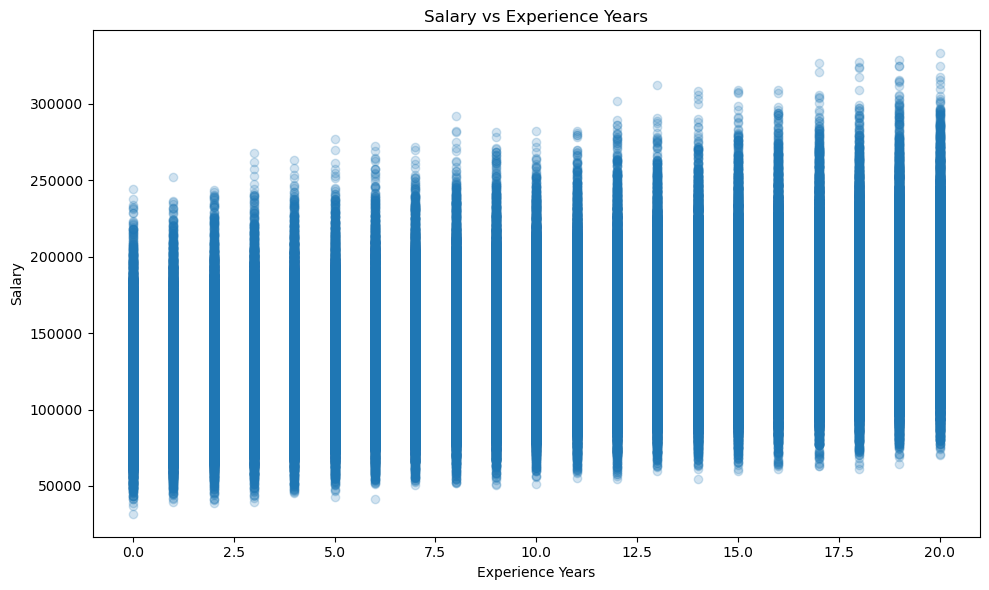

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
plt.scatter(df['experience_years'], df['salary'], alpha=0.2)
ax.set_title('Salary vs Experience Years')
ax.set_xlabel('Experience Years')
ax.set_ylabel('Salary')
plt.tight_layout()
plt.show()

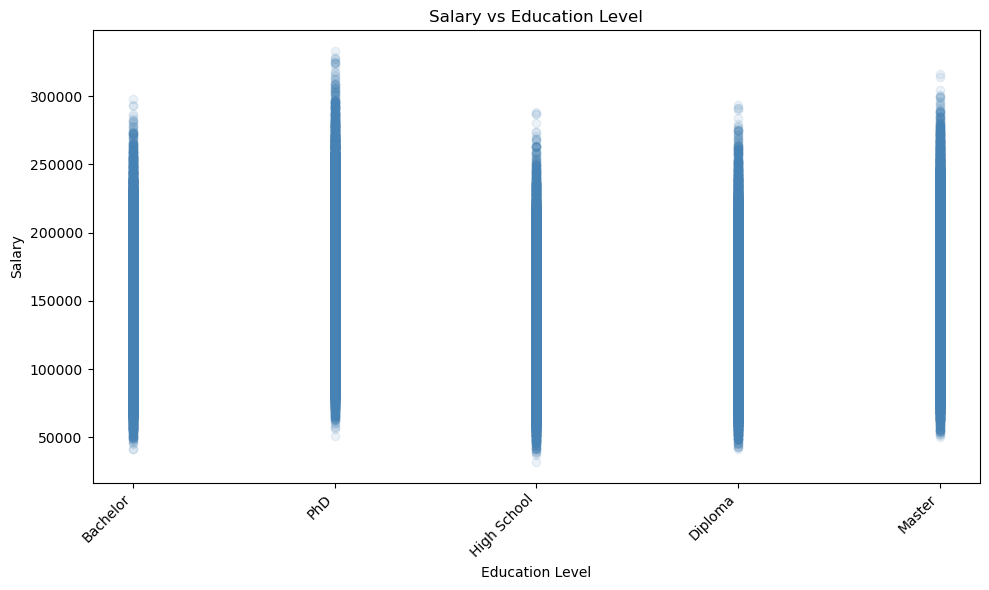

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['education_level'], df['salary'], alpha=0.1, color='steelblue')
ax.set_title('Salary vs Education Level')
ax.set_xlabel('Education Level')
ax.set_ylabel('Salary')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Line Chart

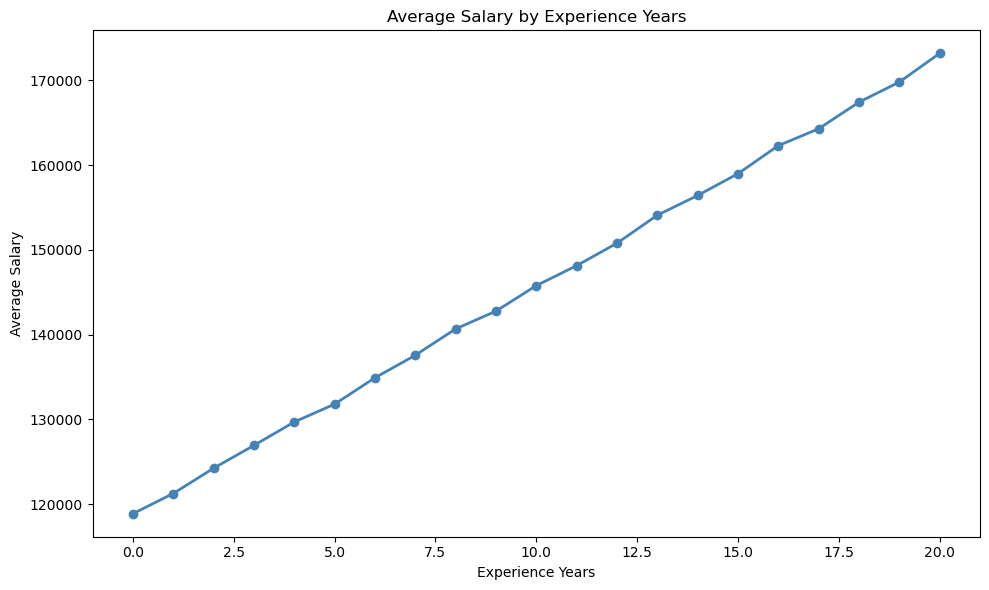

In [19]:
data = df.groupby('experience_years')['salary'].mean()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(data.index, data.values, marker='o', color='steelblue', linewidth=2)
ax.set_title('Average Salary by Experience Years')
ax.set_xlabel('Experience Years')
ax.set_ylabel('Average Salary')
plt.tight_layout()
plt.show()

### Logistic Regression from scratch

#### To do the Logistic Regression we need to have only numbers in your data, pandas read the csv as word and numbers but numpy does not do the same ,numpy is for numbers. Logistic Regression use only number so we are going to convert pandas as numpy to process.

In [20]:
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2.0,109413
1,Data Analyst,5,Bachelor,9,Telecom,Small,Australia,No,0.0,145718
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1.0,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,certifications,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0.0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1.0,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2.0,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0.0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,India,Hybrid,5.0,90467


In [21]:
df['job_title']       = df['job_title'].astype('category').cat.codes
df['education_level'] = df['education_level'].astype('category').cat.codes
df['industry']        = df['industry'].astype('category').cat.codes
df['company_size']    = df['company_size'].astype('category').cat.codes
df['location']        = df['location'].astype('category').cat.codes
df['remote_work']     = df['remote_work'].astype('category').cat.codes
data = df.values
data

array([[0, 10, 0, ..., 0, 2.0, 109413],
       [5, 5, 0, ..., 1, 0.0, 145718],
       [8, 18, 4, ..., 1, 1.0, 148123],
       ...,
       [2, 1, 0, ..., 2, 0.0, 75988],
       [6, 0, 2, ..., 0, 5.0, 90467],
       [5, 16, 2, ..., 1, 5.0, 133084]], dtype=object)

In [22]:
df['certifications'] = pd.to_numeric(df['certifications'], errors='coerce').fillna(0).astype(int)
data = df.values
data

array([[     0,     10,      0, ...,      0,      2, 109413],
       [     5,      5,      0, ...,      1,      0, 145718],
       [     8,     18,      4, ...,      1,      1, 148123],
       ...,
       [     2,      1,      0, ...,      2,      0,  75988],
       [     6,      0,      2, ...,      0,      5,  90467],
       [     5,     16,      2, ...,      1,      5, 133084]])

In [23]:
y=np.c_[data[:,9]]
y

array([[109413],
       [145718],
       [148123],
       ...,
       [ 75988],
       [ 90467],
       [133084]])

#### Y in our data is considering to be the salary column , but in logistic regression the goal is to predict experiences by resulting in conclusion.For our case the conclusion will be the classification of salary :  High salary and low salary

In [24]:
median = np.median(y)
y_class = (y > median).astype(int) 
print(median)                       
print(np.unique(y_class, return_counts=True)) 

143453.0
(array([0, 1]), array([125002, 124998], dtype=int64))


In [25]:
X = np.c_[data[:, 0:9]]
y = y_class.astype(float)
m = y.size
X_ext = np.c_[np.ones(m), X]

In [26]:
X

array([[ 0, 10,  0, ...,  3,  0,  2],
       [ 5,  5,  0, ...,  0,  1,  0],
       [ 8, 18,  4, ...,  6,  1,  1],
       ...,
       [ 2,  1,  0, ...,  3,  2,  0],
       [ 6,  0,  2, ...,  3,  0,  5],
       [ 5, 16,  2, ...,  8,  1,  5]])

In [27]:
y

array([[0.],
       [1.],
       [1.],
       ...,
       [0.],
       [0.],
       [0.]])

high_salary
0    193595
1     56405
Name: count, dtype: int64


C:\Users\marie\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


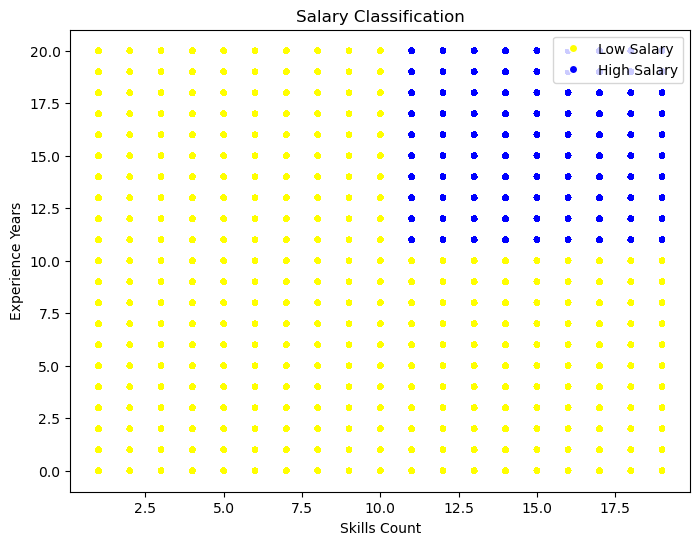

In [29]:
# Define target
df['high_salary'] = ((df['experience_years'] > 10) & (df['skills_count'] > 10)).astype(int)

# Check balance
print(df['high_salary'].value_counts())

# Scatter plot
colors = df['high_salary'].map({0: 'yellow', 1: 'blue'})
plt.figure(figsize=(8, 6))
plt.scatter(df['skills_count'], df['experience_years'], c=colors, alpha=0.3, s=10)
plt.xlabel('Skills Count')
plt.ylabel('Experience Years')
plt.title('Salary Classification')
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='yellow', label='Low Salary'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', label='High Salary')
]
plt.legend(handles=legend_elements)
plt.show()

#### My dataset is very large, which makes it difficult to analyze all features at once. To simplify the problem, I define a target variable and focus on only a few important features. This makes the patterns clearer and helps me better understand the relationships in the data before scaling up.

In [29]:
extremes = pd.concat([
    df.nsmallest(10, 'experience_years'),
    df.nlargest(10, 'experience_years'),
    df.nsmallest(10, 'skills_count'),
    df.nlargest(10, 'skills_count')
])
rest = df.drop(extremes.index).sample(n=4960, random_state=42)
df_sample = pd.concat([extremes, rest]).reset_index(drop=True)

#  EXTRACT FEATURES 
X_raw = df_sample[['experience_years', 'skills_count']].values

#  NEW Y WITH LOGICAL RULE
y = ((df_sample['experience_years'] > 10) & 
     (df_sample['skills_count'] > 8)).astype(int).values

X_mean = X_raw.mean(axis=0)
X_std  = X_raw.std(axis=0)
X_norm = (X_raw - X_mean) / X_std

print("X_norm shape:", X_norm.shape)
print("y shape:", y.shape)

X_norm shape: (5000, 2)
y shape: (5000,)


In [30]:
def sigmoid(z):
    sig = 1/(1+np.exp(-z))
    return sig

In [31]:
sigmoid(0)

0.5

### Cost Function

In [32]:
def costFunction(X, y,theta=np.zeros(3)):
    m = y.size
    X_extend = np.c_[np.ones(m), X]
    z = X_extend.dot(theta)
    h = sigmoid(z)
    cost = (-1/m) * np.sum(y*np.log(h) + (1-y)*np.log(1-h))
    return cost

In [33]:
costFunction( X_norm,y )

0.6931471805599454

In [34]:
print(y.shape)

(5000,)


### GradientDescent

In [35]:
def gradientDescent(X, y, theta=np.zeros((3)), epochs = 1000, learning_rate = 0.01):
    
    m = y.size
    X_extend = np.c_[np.ones(m),X].astype(float)
    j_history = np.zeros(epochs) 

    n_print = epochs//10

    for i in range(epochs):
        
        z = X_extend.dot(theta)
        h = sigmoid(z)
        epsilon = 1e-15  # Small value to prevent log(0)
        # Clip predictions to avoid 0 and 1
        h = np.clip(h, epsilon, 1 - epsilon)
        
        
        theta = theta-learning_rate*(1/m)*X_extend.T.dot(h-y)
        j =  (-1/m)*np.sum(y*np.log(h)+[1-y]*np.log(1-h))
        j_history[i]= j
        
        if (i+1) % n_print == 0:
            print("Iteration", i+1, " | Cost: ", j, "\n")
    
    return  theta, j_history

In [36]:
theta , j_history = gradientDescent( X_norm , y, epochs=1000)

Iteration 100  | Cost:  0.572081545948378 

Iteration 200  | Cost:  0.4955829032969072 

Iteration 300  | Cost:  0.4447236894449038 

Iteration 400  | Cost:  0.4087544665626145 

Iteration 500  | Cost:  0.3819992118787226 

Iteration 600  | Cost:  0.3612935059168245 

Iteration 700  | Cost:  0.3447630816819593 

Iteration 800  | Cost:  0.3312351634114352 

Iteration 900  | Cost:  0.3199405215811531 

Iteration 1000  | Cost:  0.310354109108851 



In [37]:
theta

array([-0.97271333,  1.15804769,  0.96471035])

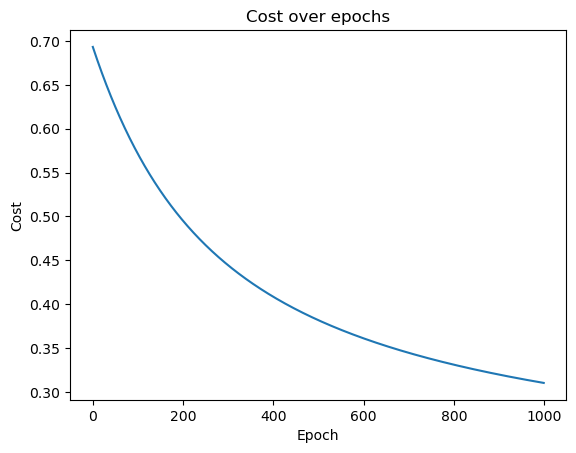

In [38]:
plt.plot(j_history)
plt.title('Cost over epochs')
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.show()

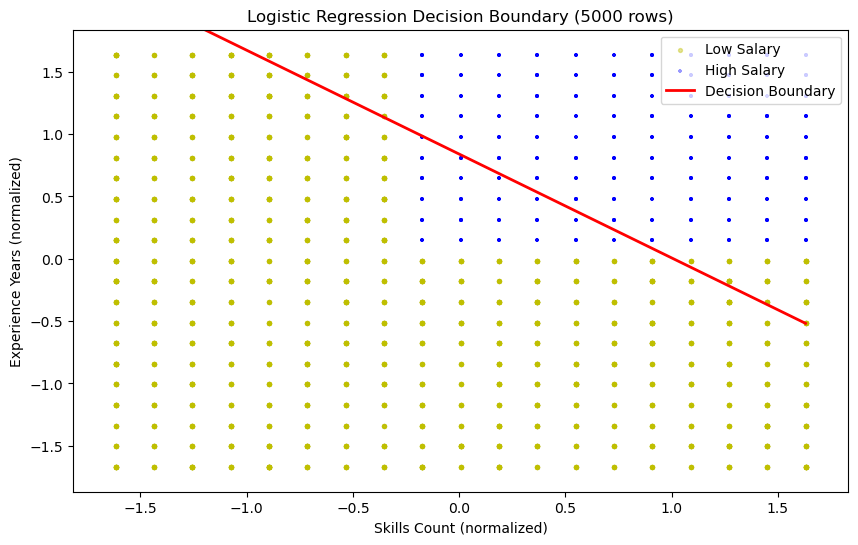

In [39]:
pos = np.where(y == 1)[0]
neg = np.where(y == 0)[0]

x_plot = np.linspace(X_norm[:, 1].min(), X_norm[:, 1].max(), 100)
y_plot = -(theta[0] + theta[2] * x_plot) / theta[1]

plt.figure(figsize=(10, 6))
plt.scatter(X_norm[neg, 1], X_norm[neg, 0],
            marker='o', c='y', s=8, alpha=0.4, label='Low Salary')
plt.scatter(X_norm[pos, 1], X_norm[pos, 0],
            marker='+', c='b', s=8, alpha=0.4, label='High Salary')
plt.plot(x_plot, y_plot, 'r-', linewidth=2, label='Decision Boundary')
plt.xlabel('Skills Count (normalized)')
plt.ylabel('Experience Years (normalized)')
plt.xlim(X_norm[:, 1].min() - 0.2, X_norm[:, 1].max() + 0.2)
plt.ylim(X_norm[:, 0].min() - 0.2, X_norm[:, 0].max() + 0.2)
plt.legend()
plt.title('Logistic Regression Decision Boundary (5000 rows)')
plt.show()

In [40]:
def predict(X, theta):
    m = len(X)
    X_extend = np.c_[np.ones(m), X]
    h = sigmoid(X_extend.dot(theta))
    return (h >= 0.5).astype(int)

In [41]:
new_person_raw = np.array([[18, 10]])  # experience=18, skills=10
new_person_norm = (new_person_raw - X_mean) / X_std
result = predict(new_person_norm, theta)
print("High Salary" if result[0] == 1 else "Low Salary")

High Salary


### Logistic Regression with Scikit-Learn library

In [86]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import log_loss

In [87]:
data=pd.read_csv('data/job_salary_prediction_dataset.csv')
data

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467


In [88]:
data['high_salary'] = (data['salary'] > data['salary'].median()).astype(int)
data

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,high_salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413,0
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764,0
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123,1
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123,1
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069,1
...,...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791,0
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593,1
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988,0
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467,0


In [89]:
data = data.drop(columns=['education_level', 'company_size', 'remote_work'])
data = data.drop(columns=['salary'])
data

,job_title,experience_years,skills_count,industry,location,certifications,high_salary
0,AI Engineer,10,2,Healthcare,India,2,0
1,Data Analyst,5,17,Telecom,Australia,0,0
2,Frontend Developer,18,4,Media,Singapore,1,1
3,Business Analyst,19,13,Retail,Canada,0,1
4,Product Manager,15,7,Manufacturing,Sweden,0,1
...,...,...,...,...,...,...,...
249995,Software Engineer,17,2,Telecom,India,1,0
249996,Frontend Developer,20,7,Telecom,Remote,2,1
249997,Business Analyst,1,12,Retail,India,0,0
249998,Data Scientist,0,2,Consulting,Sweden,5,0


In [90]:
X = data.drop(columns=['high_salary'])
y = data['high_salary']

In [91]:
X

,job_title,experience_years,skills_count,industry,location,certifications
0,AI Engineer,10,2,Healthcare,India,2
1,Data Analyst,5,17,Telecom,Australia,0
2,Frontend Developer,18,4,Media,Singapore,1
3,Business Analyst,19,13,Retail,Canada,0
4,Product Manager,15,7,Manufacturing,Sweden,0
...,...,...,...,...,...,...
249995,Software Engineer,17,2,Telecom,India,1
249996,Frontend Developer,20,7,Telecom,Remote,2
249997,Business Analyst,1,12,Retail,India,0
249998,Data Scientist,0,2,Consulting,Sweden,5


In [92]:
y

0         0
1         0
2         1
3         1
4         1
         ..
249995    0
249996    1
249997    0
249998    0
249999    0
Name: high_salary, Length: 250000, dtype: int32

In [93]:
X = pd.get_dummies(X)
X

,experience_years,skills_count,certifications,job_title_AI Engineer,job_title_Backend Developer,job_title_Business Analyst,job_title_Cloud Engineer,job_title_Cybersecurity Analyst,job_title_Data Analyst,job_title_Data Scientist,...,location_Australia,location_Canada,location_Germany,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA
0,10,2,2,True,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
1,5,17,0,False,False,False,False,False,True,False,...,True,False,False,False,False,False,False,False,False,False
2,18,4,1,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
3,19,13,0,False,False,True,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
4,15,7,0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,17,2,1,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
249996,20,7,2,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
249997,1,12,0,False,False,True,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
249998,0,2,5,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False


In [94]:
X = X.astype(int)
X

,experience_years,skills_count,certifications,job_title_AI Engineer,job_title_Backend Developer,job_title_Business Analyst,job_title_Cloud Engineer,job_title_Cybersecurity Analyst,job_title_Data Analyst,job_title_Data Scientist,...,location_Australia,location_Canada,location_Germany,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA
0,10,2,2,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,5,17,0,0,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
2,18,4,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,19,13,0,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,15,7,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,17,2,1,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
249996,20,7,2,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
249997,1,12,0,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
249998,0,2,5,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0


In [95]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.2)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(200000, 35)
(50000, 35)
(200000,)
(50000,)


In [96]:
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_norm = (X - X_mean) / X_std

In [97]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.2, random_state=42)

In [98]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [101]:
# Select only 3 features
X_top3 = X[['experience_years', 'skills_count', 'certifications']]

# Normalize
X_mean3 = X_top3.mean(axis=0)
X_std3 = X_top3.std(axis=0)
X_norm3 = (X_top3 - X_mean3) / X_std3

# Split
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X_norm3, y, test_size=0.2, random_state=42)

# Train
model3 = LogisticRegression(max_iter=1000)
model3.fit(X_train3, y_train3)

# Evaluate
y_pred3 = model3.predict(X_test3)
print(f"Accuracy: {accuracy_score(y_test3, y_pred3)*100:.2f}%")
print(classification_report(y_test3, y_pred3,
      target_names=['Low Salary', 'High Salary']))



Accuracy: 66.62%
              precision    recall  f1-score   support

  Low Salary       0.66      0.67      0.67     24953
 High Salary       0.67      0.66      0.67     25047

    accuracy                           0.67     50000
   macro avg       0.67      0.67      0.67     50000
weighted avg       0.67      0.67      0.67     50000



C:\Users\marie\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


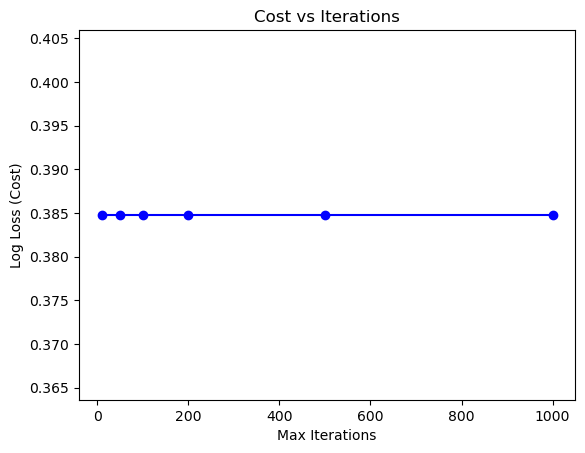

In [85]:
costs = []
iterations = [10, 50, 100, 200, 500, 1000]

for n in iterations:
    m = LogisticRegression(max_iter=n, warm_start=False)
    m.fit(X_train, y_train)
    p = m.predict_proba(X_test)
    costs.append(log_loss(y_test, p))

plt.plot(iterations, costs, 'b-o')
plt.xlabel('Max Iterations')
plt.ylabel('Log Loss (Cost)')
plt.title('Cost vs Iterations')
plt.show()

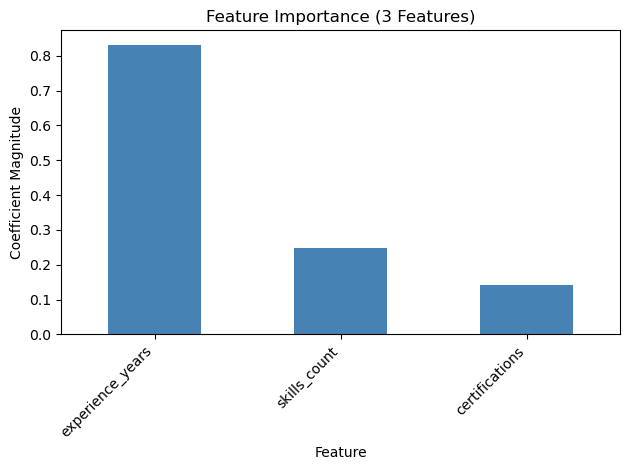

In [102]:
feature_names3 = X_top3.columns.tolist()
importance3 = pd.Series(model3.coef_[0], index=feature_names3)

importance3.abs().sort_values(ascending=False).plot(kind='bar', color='steelblue')
plt.title('Feature Importance (3 Features)')
plt.xlabel('Feature')
plt.ylabel('Coefficient Magnitude')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [103]:
# New person: 8 years experience, 6 skills, 2 certifications
new_person3 = np.array([[10, 1, 2]])
new_person3_norm = (new_person3 - X_mean3.values) / X_std3.values

pred3 = model3.predict(new_person3_norm)
proba3 = model3.predict_proba(new_person3_norm)

print("=== Simple Model (3 features) ===")
print("Prediction:", "High Salary" if pred3[0]==1 else "Low Salary")
print(f"Confidence: {max(proba3[0])*100:.2f}%")

=== Simple Model (3 features) ===
Prediction: Low Salary
Confidence: 61.03%


C:\Users\marie\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\marie\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [104]:
def predict_salary(experience_years, skills_count, certifications, 
                   job_title=None, location=None, industry=None):
    
    # Create empty row with all 32 columns set to 0
    new_person = pd.DataFrame(np.zeros((1, len(X.columns))), columns=X.columns)
    
    # Fill numeric features
    new_person['experience_years'] = experience_years
    new_person['skills_count'] = skills_count
    new_person['certifications'] = certifications
    
    # Fill categorical features if provided
    if job_title and f'job_title_{job_title}' in X.columns:
        new_person[f'job_title_{job_title}'] = 1
    if location and f'location_{location}' in X.columns:
        new_person[f'location_{location}'] = 1
    if industry and f'industry_{industry}' in X.columns:
        new_person[f'industry_{industry}'] = 1

    # Normalize
    new_norm = pd.DataFrame(
        (new_person.values - X_mean.values) / X_std.values,
        columns=X.columns)
    
    pred = model.predict(new_norm)
    proba = model.predict_proba(new_norm)
    
    print("=== Full Model ===")
    print("Prediction:", "High Salary" if pred[0]==1 else "Low Salary")
    print(f"Confidence: {max(proba[0])*100:.2f}%")


In [105]:
predict_salary(20, 2, 5, job_title='Data Analyst', location='USA')

=== Full Model ===
Prediction: High Salary
Confidence: 92.55%
